# Pneumonia Detection with DenseNet-121
**Overview:**  
Train using DenseNet-121—initialized from ImageNet and from scratch—to classify chest X-rays as **Normal** vs. **Pneumonia**.  
Key features:  
- Stratified weighted sampling to address class imbalance  
- Data augmentation
- Early stopping  
- Evaluation metrics: confusion matrices, ROC curves, Accuracy, Precision, F1, Recall

# Problem Statement

How can transfer learning with a DenseNet-121 architecture be effectively applied to a limited chest X-ray dataset to produce a robust, accurate binary classifier for pneumonia detection—while minimizing overfitting and ensuring clinical applicability?  
(To analyzes chest X-ray images to distinguish pneumonia from normal cases.)

#**Transfer learning**
It consists of taking features learned on one problem, and
leveraging them on a new, similar problem.
Transfer learning is usually done for tasks where our dataset has too little data to
 train a full-scale model from scratch.

The most common incarnation of transfer learning in the context of deep learning is the
 following workflow:

1. Take layers from a previously trained model.
2. Freeze them, so as to avoid destroying any of the information they contain during
 future training rounds.
3. Add some new, trainable layers on top of the frozen layers. They will learn to turn
 the old features into predictions on a  new dataset.
4. Train the new layers on your dataset.

##DenseNet 121

"DenseNet" stands for Dense Convolutional Network.
The "121" refers to the number of layers in the network.
Unlike traditional CNNs that pass information only from one layer to the next, DenseNets connect each layer to all preceding layers—fostering extensive feature reuse and smoother gradient flow for more efficient training and superior image-classification performance.


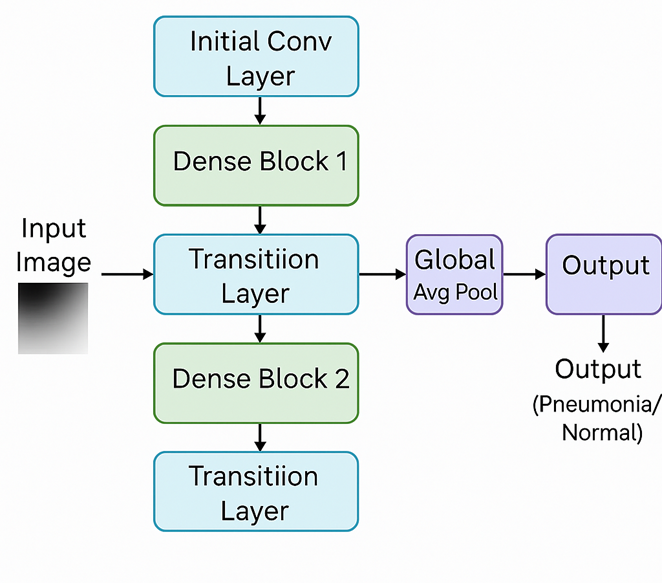

## Libraries

In [ ]:
import numpy as np
import pandas as pd
import torch
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
from datetime import datetime

# About the dataset


Dataset is from Kaggle : https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).

Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.

For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.

##Data Loading

We use the `ImageFolder` class from PyTorch's torchvision library to load images structured into `train`, `val`, and `test` folders.
Each folder contains subdirectories for the two classes: `NORMAL` and `PNEUMONIA`. This structure allows for easy labeling and efficient loading of batches with the `DataLoader`.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/chest-xray-pneumonia.zip'


In [ ]:
import zipfile
import os
extract_path = '/content'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
print("Contents:", os.listdir('/content/chest_xray'))

Contents: ['train', 'val', 'test']


###Declaring the path

In [ ]:
train_folder= '/content/chest_xray/train/'
val_folder = '/content/chest_xray/val/'
test_folder = '/content/chest_xray/test/'

#labelling: n=normal, p=pneumonia

train_n = train_folder+'NORMAL/'
train_p = train_folder+'PNEUMONIA/'

test_n = test_folder+'NORMAL/'
test_p = test_folder+'PNEUMONIA/'

val_n = val_folder+'NORMAL/'
val_p = val_folder+'PNEUMONIA/'

In [ ]:
print(f"Train - Normal: {len(os.listdir(train_n))}")
print(f"Train - Pneumonia: {len(os.listdir(train_p))}")
dataset_names = ["train", "test", "val"]  # Renamed to avoid conflict
labels = ["_n", "_p"]

sizeDict = {}

for dataset in dataset_names:
    for label in labels:
        sizeDict[dataset+label] = len(os.listdir(locals()[dataset+label]))

Train - Normal: 1800
Train - Pneumonia: 3875


# Train, Test and Validation split
Train - 80%

Test - 10%

Validation - 10%

Text(0.5, 1.0, 'Train, Test and Validation split')

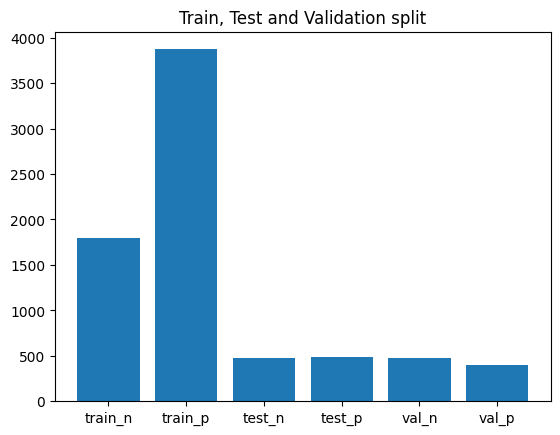

In [ ]:
import matplotlib.pyplot as plt

plt.bar(sizeDict.keys(), sizeDict.values())
plt.title(label="Train, Test and Validation split")

In [ ]:
os.listdir(train_folder)

['NORMAL', 'PNEUMONIA']

Text(0.5, 1.0, 'Pneumonia')

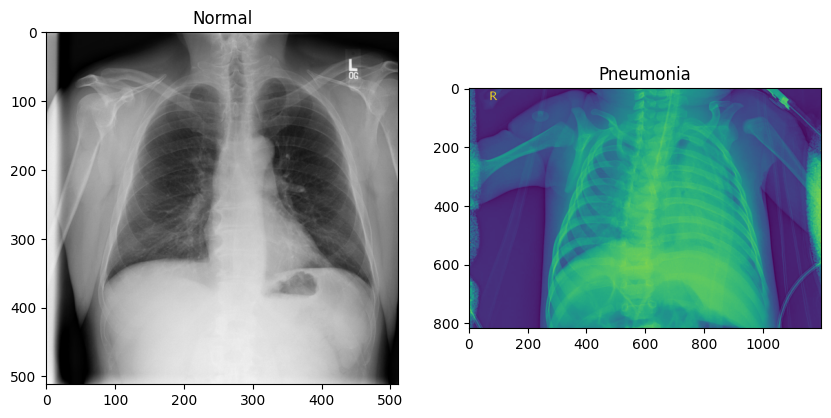

In [ ]:
#normal
n_pic = os.listdir(train_n)[23]
n_pic_address = train_n+n_pic

#Pneumonia
p_pic =  os.listdir(train_p)[23]
p_pic_address = train_p+p_pic

# Load the images
n_load = Image.open(n_pic_address)
p_load = Image.open(p_pic_address)

#Let's plt these images
f = plt.figure(figsize= (10,6))
a1 = f.add_subplot(1,2,1)
img_plot = plt.imshow(n_load)
a1.set_title('Normal')

a2 = f.add_subplot(1, 2, 2)
img_plot = plt.imshow(p_load)
a2.set_title('Pneumonia')

In [ ]:
from sklearn.model_selection import train_test_split
random_seed =0
BATCH_SIZE = 20
IMG_RESIZE = (256, 256)
torch.manual_seed(random_seed)

## Gaussian Noise
Adding Gaussian noise simulates real-world sensor and acquisition variability in X-ray scans. By forcing the network to learn despite small pixel-level perturbations, it becomes more robust to noise in unseen images and less prone to overfitting.

In [ ]:
class AddGaussianNoise(object):
    def __init__(self, mean=0., std=0.05):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"


## Data Augmentation

To improve generalization and handle class imbalance, we apply augmentations only on the training set.

Techniques used:
- Random rotation
- Horizontal Flip
- Color jitter
- Affine transformations
- Gaussian noise


> Use of Horizontal Flip on Chest X-Rays  

Posterior–anterior chest X-rays exhibit near-bilateral symmetry in lung appearance and pathology. Applying a horizontal flip effectively doubles our normal‐class samples without introducing unnatural artifacts, helping the model learn invariance to minor positioning shifts while preserving clinical realism.


In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets

train_transformer = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # small shifts
    transforms.RandomEqualize(),  # for histogram flattening
    transforms.ToTensor(),
    AddGaussianNoise(0., 0.02),
])

test_transformer = transforms.Compose([
                                  transforms.Resize(IMG_RESIZE),
                                  transforms.CenterCrop(224),
                                  transforms.ToTensor(),
                                  ])


train_imgs = datasets.ImageFolder(root=train_folder, transform=test_transformer)

train_indices, valid_indices = train_test_split(list(range(len(train_imgs.targets))), test_size=0.1, stratify=train_imgs.targets)
train_dataset = torch.utils.data.Subset(train_imgs, train_indices)
valid_dataset = torch.utils.data.Subset(train_imgs, valid_indices)

def make_subset_weights(subset, nclasses):
    count = [0] * nclasses
    for i in subset.indices:
        label = subset.dataset.imgs[i][1]
        count[label] += 1

    weight_per_class = [0.] * nclasses
    N = float(sum(count))
    for i in range(nclasses):
        weight_per_class[i] = N / float(count[i])

    weights = [0] * len(subset)
    for idx, original_idx in enumerate(subset.indices):
        label = subset.dataset.imgs[original_idx][1]
        weights[idx] = weight_per_class[label]

    return torch.FloatTensor(weights)


train_weights = make_subset_weights(train_dataset, nclasses=2)
valid_weights = make_subset_weights(valid_dataset, nclasses=2)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    sampler=WeightedRandomSampler(train_weights, len(train_weights)),
    pin_memory=True
)

val_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    sampler=WeightedRandomSampler(valid_weights, len(valid_weights)),
    pin_memory=True
)


In [ ]:
from torchvision.datasets import ImageFolder
preview_dataset = datasets.ImageFolder(train_folder, transform=test_transformer)
print(preview_dataset.classes)
print(len(preview_dataset))

['NORMAL', 'PNEUMONIA']
5675


# Distribution of images in the training dataset


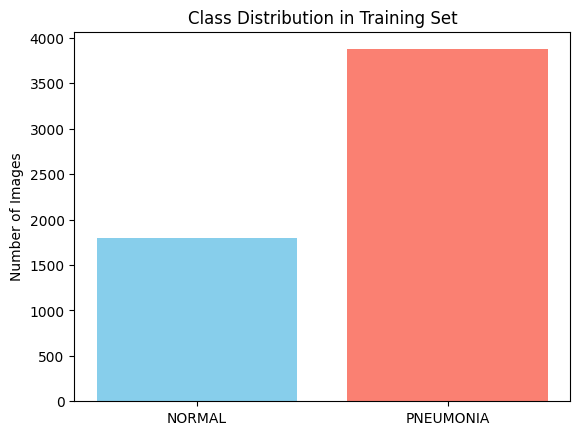

Class counts: {'NORMAL': 1800, 'PNEUMONIA': 3875}


In [ ]:
from collections import Counter
from matplotlib import pyplot as plt

# Show class distribution
class_counts = Counter(train_imgs.targets)
labels = train_imgs.classes
counts = [class_counts[i] for i in range(len(labels))]

plt.bar(labels, counts, color=['skyblue', 'salmon'])
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Images")
plt.show()

print("Class counts:", dict(zip(labels, counts)))


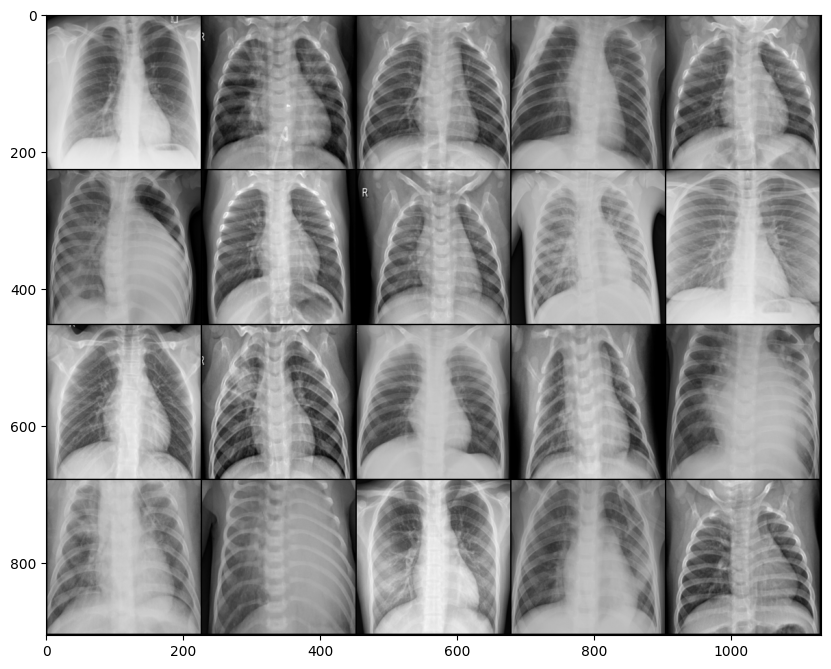

In [ ]:
from torchvision.utils import make_grid

def show_batch(data_loader):
    for images, labels in data_loader:
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(make_grid(images[:20], nrow=5).permute(1, 2, 0))
        break

show_batch(train_loader)

#Defining the Model

We use **DenseNet121**, a CNN architecture with dense connections that reuse features and reduce overfitting.
The model is initialized with pretrained ImageNet weights when (`pretrained=True`) to leverage transfer learning.
We then replace the final fully connected layer to match our 2-class pneumonia classification task.


In [ ]:
def train(train_loader, model, criterion, optimizer, device):

  model.train()
  running_loss = 0

  for batch in train_loader:
    X, y_true = batch

    optimizer.zero_grad()

    X = X.to(device)
    y_true = y_true.to(device)

    y_hat = model(X)
    loss = criterion(y_hat, y_true)
    running_loss += loss.item() * X.size(0)

    # Backward Pass - Adjust weights based on the loss
    loss.backward()
    optimizer.step()

  epoch_loss = running_loss / len(train_loader.dataset)
  return model, optimizer, epoch_loss

def validate(val_loader, model, criterion, device):

  model.eval()
  running_loss = 0

  for batch in val_loader:
    X, y_true = batch

    X = X.to(device)
    y_true = y_true.to(device)

    # Forward Pass
    y_hat = model(X)

    loss = criterion(y_hat, y_true)
    running_loss += loss.item() * X.size(0)

  epoch_loss = running_loss / len(val_loader.dataset)
  return model, epoch_loss


def get_accuracy(model, data_loader, device):

  correct_pred = 0
  n = 0

  with torch.no_grad():
    model.eval()
    for batch in data_loader:
      X, y_true = batch


      X = X.to(device)
      y_true = y_true.to(device)

      y_prob = model(X)
      _, predicted_labels = torch.max(y_prob, 1)

      n += y_true.size(0)
      correct_pred += (predicted_labels == y_true).sum()

  return correct_pred.float() / n

#Plots

def plot_losses(train_losses, valid_losses):

  plt.style.use('ggplot')

  train_losses = np.array(train_losses)
  valid_losses = np.array(valid_losses)

  fig, ax = plt.subplots(figsize = (8, 4.5))

  ax.plot(train_losses, color='blue', label='Training loss')
  ax.plot(valid_losses, color='red', label='Validation loss')
  ax.set(title="Loss over epochs",
         xlabel='Epoch',
         ylabel='Loss')
  ax.legend()
  fig.show()

  plt.style.use('default')

def plot_accuracies(train_accs, valid_accs):


  plt.style.use('ggplot')

  train_accs = np.array(train_accs)
  valid_accs = np.array(valid_accs)

  fig, ax = plt.subplots(figsize = (8, 4.5))

  ax.plot(train_accs, color='blue', label='Training Accuracy')
  ax.plot(valid_accs, color='red', label='Validation Accuracy')
  ax.set(title="Classification Accuracy Over Epochs",
         xlabel='Epoch',
         ylabel='Accuracy')
  ax.legend()
  fig.show()

  plt.style.use('default')


## Training Loop with early stopping

We train for up to `N_EPOCHS`, but stop early if validation loss doesn’t improve for 5 epochs.

> No Model Checkpointing

In the experiment, validation loss decreased smoothly and plateaued before triggering early stopping, so checkpoint provided negligible benefit. We therefore selected the final model on‐the‐fly at the epoch with the lowest validation loss to keep training simple and efficient.



In [ ]:
def training_loop(model, criterion, optimizer, train_loader, val_loader, epochs, device, print_every=1):

  # Set objects for storing metrics
  best_loss = 1e10
  train_losses = []
  valid_losses = []
  train_accs = []
  valid_accs = []

  # Training Loop
  best_val_loss = float("inf")
  patience = 5
  trigger_times = 0

  for epoch in range(epochs):
      model, optimizer, train_loss = train(train_loader, model, criterion, optimizer, device)
      train_losses.append(train_loss)

      with torch.no_grad():
          model, valid_loss = validate(val_loader, model, criterion, device)
          valid_losses.append(valid_loss)

      # Early stopping check
      if valid_loss < best_val_loss:
          best_val_loss = valid_loss
          trigger_times = 0
      else:
          trigger_times += 1
          if trigger_times >= patience:
              print("Early stopping triggered.")
              break

      # Compute and store accuracy
      train_acc = get_accuracy(model, train_loader, device=device)
      valid_acc = get_accuracy(model, val_loader, device=device)

      train_accs.append(train_acc.cpu().item())
      valid_accs.append(valid_acc.cpu().item())

      print(f'{datetime.now().time().replace(microsecond=0)} --- '
            f'Epoch: {epoch}\t'
            f'Train loss: {train_loss:.4f}\t'
            f'Valid loss: {valid_loss:.4f}\t'
            f'Train accuracy: {100 * train_acc:.2f}\t'
            f'Valid accuracy: {100 * valid_acc:.2f}')

  scheduler.step()
  plot_losses(train_losses, valid_losses)
  plot_accuracies(train_accs, valid_accs)

  return model, optimizer, (train_losses, valid_losses)

## Parameters

In [ ]:
LEARNING_RATE = 0.001
N_EPOCHS = 30
N_CLASSES = 2
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [ ]:
import torch.nn as nn
from collections import OrderedDict

#Freezing the upper layer

for parameter in model.parameters():
  parameter.requires_grad = False

in_features = model.classifier.in_features
features = list(model.classifier.children())[:-1]
features.extend([nn.Linear(in_features, 2)])


model.classifier = nn.Sequential(OrderedDict([
    ('fc1', nn.Linear(in_features, 64)),
    ('relu1', nn.ReLU()),
    ('drop1', nn.Dropout(0.5)),
    ('fc2', nn.Linear(64, 2))
]))



## Optimizer and Scheduler

In [ ]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


In [ ]:
model.to(DEVICE)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

### Testing model connection to device and debug

In [ ]:
# Testing model connection to DEVICE
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
output = model(dummy_input)
print("Raw output shape:", output.shape)
print("Output:", output)


Raw output shape: torch.Size([1, 2])
Output: tensor([[ 0.0262, -0.1325]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [ ]:
print("Checking the datatype of one batch from val_loader")#debug
for batch in val_loader:
    print("Type of batch:", type(batch))
    if isinstance(batch, tuple) or isinstance(batch, list):
        print("Batch length:", len(batch))
        print("First item type:", type(batch[0]))
        print("Second item type:", type(batch[1]))
    else:
        print("Not a tuple. Contents:", batch)
    break  # only check one batch


Checking the datatype of one batch from val_loader
Type of batch: <class 'list'>
Batch length: 2
First item type: <class 'torch.Tensor'>
Second item type: <class 'torch.Tensor'>


# Training Without Transfer Learning

To compare the effect of transfer learning, run the training using `pretrained=False` for DenseNet121.

Expected Outcome:
- Slower convergence
- Lower initial accuracy
- Less generalization on test data

A pre-trained model is a saved network that was previously trained on a large dataset, typically on a large-scale image-classification task. You either use the pretrained model as is or use transfer learning to customize this model to a given task.

In [ ]:
model = torchvision.models.densenet121(pretrained=False)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


##With model_pretrained = false  && with Early stopping

**1. Train the model - No of Epochs = 30**

20:48:31 --- Epoch: 0	Train loss: 0.5371	Valid loss: 0.4517	Train accuracy: 85.53	Valid accuracy: 88.38
20:52:40 --- Epoch: 1	Train loss: 0.4672	Valid loss: 0.4296	Train accuracy: 86.41	Valid accuracy: 81.87
20:56:55 --- Epoch: 2	Train loss: 0.4419	Valid loss: 0.4489	Train accuracy: 87.78	Valid accuracy: 86.62
21:00:55 --- Epoch: 3	Train loss: 0.4347	Valid loss: 0.3827	Train accuracy: 89.74	Valid accuracy: 88.91
21:04:55 --- Epoch: 4	Train loss: 0.4455	Valid loss: 0.4605	Train accuracy: 86.59	Valid accuracy: 85.39
21:08:55 --- Epoch: 5	Train loss: 0.4324	Valid loss: 0.4187	Train accuracy: 89.35	Valid accuracy: 90.85
21:12:55 --- Epoch: 6	Train loss: 0.4259	Valid loss: 0.4205	Train accuracy: 89.45	Valid accuracy: 88.38
21:16:53 --- Epoch: 7	Train loss: 0.4240	Valid loss: 0.3882	Train accuracy: 90.27	Valid accuracy: 86.62
Early stopping triggered.


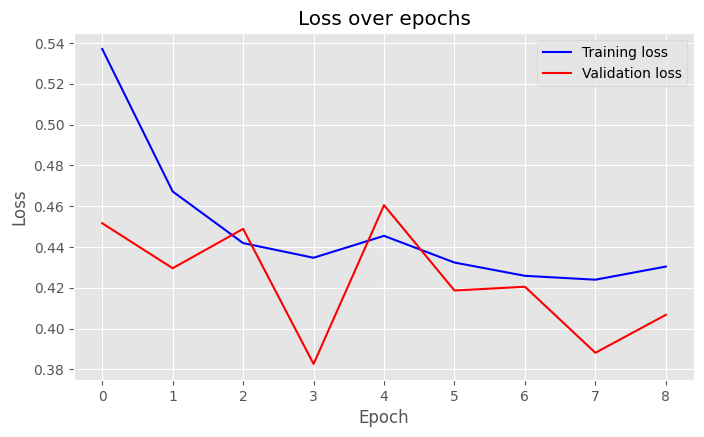

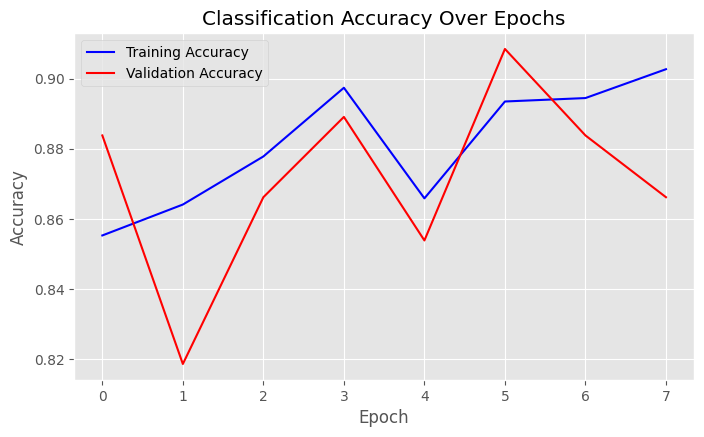

In [ ]:
model, optimizer, _ = training_loop(model, criterion, optimizer, train_loader, val_loader, N_EPOCHS, DEVICE)

Since it stopped so early but it has still room for improvement. We let it run without Early stopping for the full 30 epochs.

##With model_pretrained = false  && without Early stopping

##**1. Train the model**

No. of Epochs = 30

18:17:45 --- Epoch: 0	Train loss: 0.5919	Valid loss: 0.4461	Train accuracy: 83.98	Valid accuracy: 83.27
18:21:47 --- Epoch: 1	Train loss: 0.4953	Valid loss: 0.4365	Train accuracy: 84.20	Valid accuracy: 83.63
18:25:47 --- Epoch: 2	Train loss: 0.4829	Valid loss: 0.3851	Train accuracy: 86.14	Valid accuracy: 90.49
18:29:48 --- Epoch: 3	Train loss: 0.4687	Valid loss: 0.3925	Train accuracy: 87.17	Valid accuracy: 85.92
18:33:48 --- Epoch: 4	Train loss: 0.4526	Valid loss: 0.3886	Train accuracy: 87.21	Valid accuracy: 89.79
18:37:48 --- Epoch: 5	Train loss: 0.4493	Valid loss: 0.3747	Train accuracy: 89.13	Valid accuracy: 90.67
18:41:53 --- Epoch: 6	Train loss: 0.4537	Valid loss: 0.3466	Train accuracy: 88.53	Valid accuracy: 90.85
18:45:52 --- Epoch: 7	Train loss: 0.4424	Valid loss: 0.3766	Train accuracy: 88.53	Valid accuracy: 91.20
18:49:52 --- Epoch: 8	Train loss: 0.4417	Valid loss: 0.3636	Train accuracy: 89.72	Valid accuracy: 89.79
18:53:51 --- Epoch: 9	Train loss: 0.4441	Valid loss: 0.3773	Trai

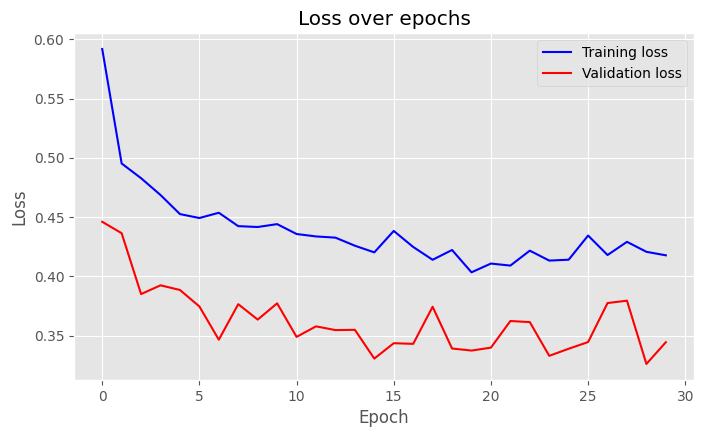

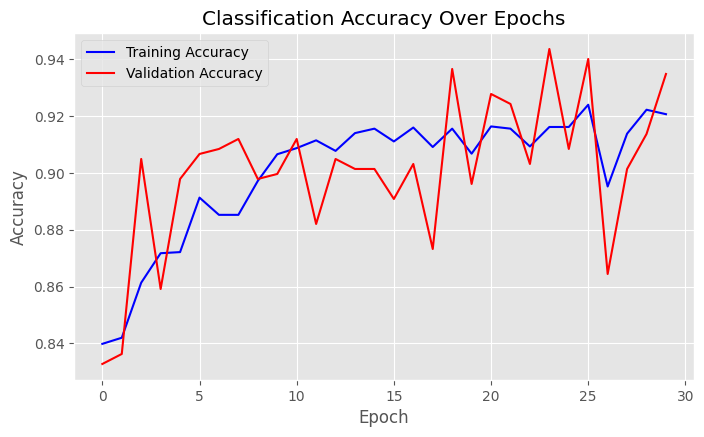

In [ ]:
model, optimizer, _ = training_loop(model, criterion, optimizer, train_loader, val_loader, N_EPOCHS, DEVICE)

##**2. Training Set Result**

Accuracy: 0.9161934599569219
Precision: 0.9279766860949209
Recall: 0.8973429951690821
Specificity: 0.9340449866565002
F1: 0.9124027834629554



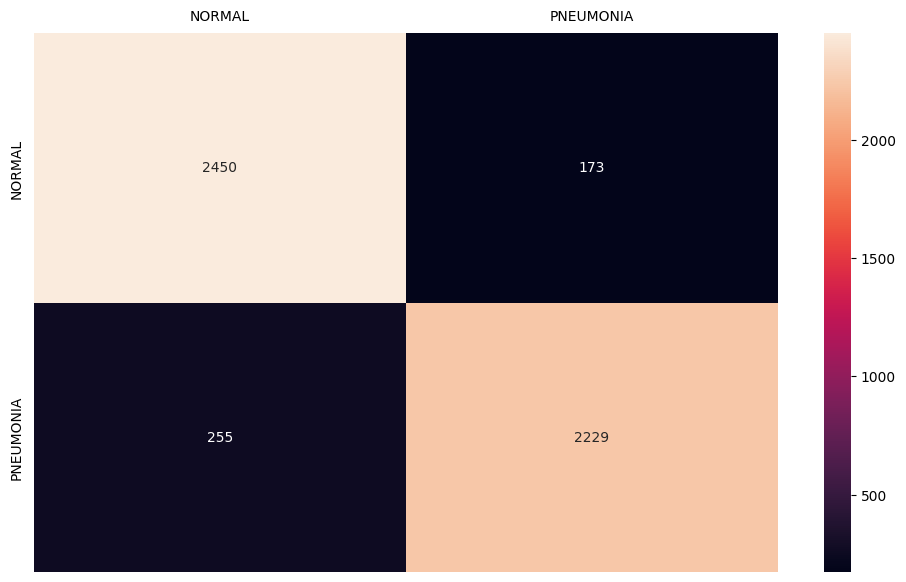

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn
import pandas as pd

test_batch_size = 20

y_pred = []
y_true = []

with torch.no_grad():
  model.eval()

  for inputs, labels in train_loader:

    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)

    probs = model(inputs)
    _, output = torch.max(probs, 1)

    output = output.data.cpu().numpy()
    y_pred.extend(output)

    labels = labels.data.cpu().numpy()
    y_true.extend(labels)

classes = ('NORMAL', 'PNEUMONIA')

cf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])

plt.figure(figsize=(12,7))
ax = sn.heatmap(df_cm, annot=True, fmt="d")
# ax.xaxis.tick_top()
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom=False, bottom=False, top=False, left=False, labeltop=True)
ax.xaxis.set_label_position("top")
plt.savefig("ConfusionMatrix.png")

tp = cf_matrix[1][1]
fp = cf_matrix[0][1]
tn = cf_matrix[0][0]
fn = cf_matrix[1][0]
accuracy = (tp + tn)/(tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)

train_accuracy = accuracy
train_precision = precision
train_recall = recall
train_specificity = specificity
train_f1 = f1

print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"Specificity: {train_specificity}")
print(f"F1: {train_f1}")
print()


##**3. Validation Set Result**

Accuracy: 0.9278169014084507
Precision: 0.9264214046822743
Recall: 0.9358108108108109
Specificity: 0.9191176470588235
F1: 0.9310924369747899



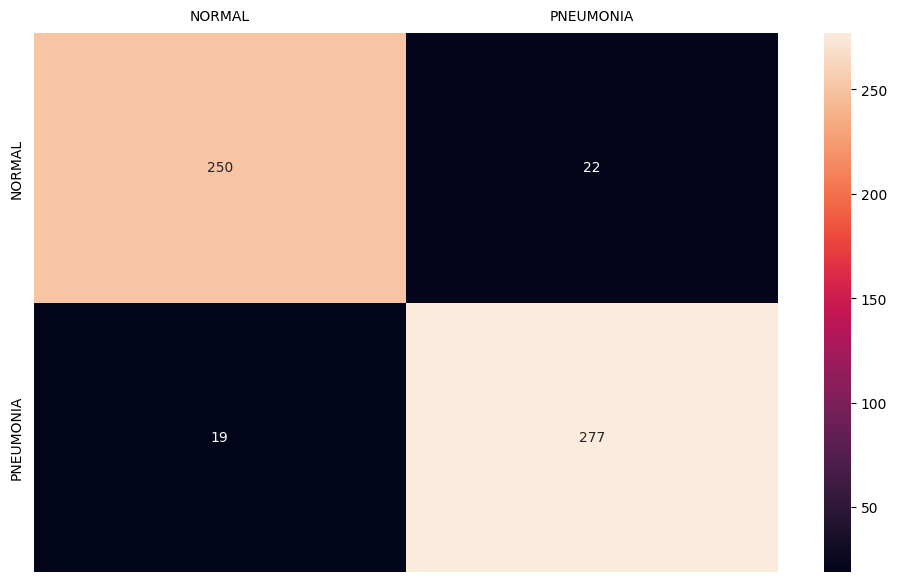

In [ ]:
test_batch_size = 20

y_pred = []
y_true = []

with torch.no_grad():
  model.eval()

  for inputs, labels in val_loader:

    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)

    probs = model(inputs)
    _, output = torch.max(probs, 1)

    output = output.data.cpu().numpy()
    y_pred.extend(output)

    labels = labels.data.cpu().numpy()
    y_true.extend(labels)

classes = ('NORMAL', 'PNEUMONIA')

cf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])

plt.figure(figsize=(12,7))
ax = sn.heatmap(df_cm, annot=True, fmt="d")
# ax.xaxis.tick_top()
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom=False, bottom=False, top=False, left=False, labeltop=True)
ax.xaxis.set_label_position("top")
plt.savefig("ConfusionMatrix.png")

tp = cf_matrix[1][1]
fp = cf_matrix[0][1]
tn = cf_matrix[0][0]
fn = cf_matrix[1][0]
accuracy = (tp + tn)/(tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)

val_accuracy = accuracy
val_precision = precision
val_recall = recall
val_specificity = specificity
val_f1 = f1

print(f"Accuracy: {val_accuracy}")
print(f"Precision: {val_precision}")
print(f"Recall: {val_recall}")
print(f"Specificity: {val_specificity}")
print(f"F1: {val_f1}")
print()


##**4. Test Set Result**

Accuracy: 0.8813735691987513
Precision: 0.8533333333333334
Recall: 0.9237113402061856
Specificity: 0.8382352941176471
F1: 0.8871287128712873



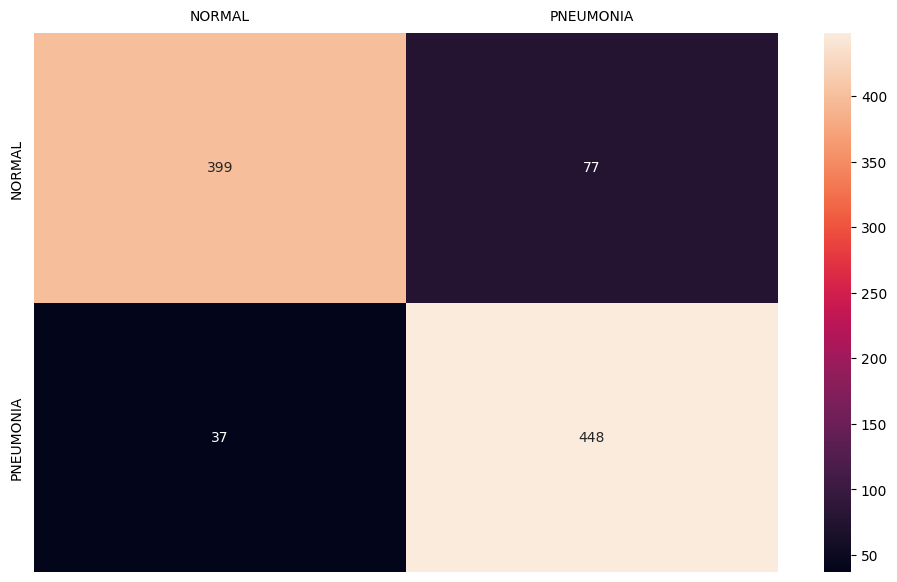

In [ ]:
test_batch_size = 20
test_dataset = ImageFolder(test_folder, transform=test_transformer)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)

y_pred = []
y_true = []

with torch.no_grad():
  model.eval()

  for inputs, labels in test_loader:

    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)

    probs = model(inputs)
    _, output = torch.max(probs, 1)

    output = output.data.cpu().numpy()
    y_pred.extend(output)

    labels = labels.data.cpu().numpy()
    y_true.extend(labels)

classes = ('NORMAL', 'PNEUMONIA')

cf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])

plt.figure(figsize=(12,7))
ax = sn.heatmap(df_cm, annot=True, fmt="d")
# ax.xaxis.tick_top()
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom=False, bottom=False, top=False, left=False, labeltop=True)
ax.xaxis.set_label_position("top")
plt.savefig("ConfusionMatrix.png")

tp = cf_matrix[1][1]
fp = cf_matrix[0][1]
tn = cf_matrix[0][0]
fn = cf_matrix[1][0]
accuracy = (tp + tn)/(tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)

test_accuracy = accuracy
test_precision = precision
test_recall = recall
test_specificity = specificity
test_f1 = f1

print(f"Accuracy: {test_accuracy}")
print(f"Precision: {test_precision}")
print(f"Recall: {test_recall}")
print(f"Specificity: {test_specificity}")
print(f"F1: {test_f1}")
print()


##**5. Receiver Operating Characteristic (ROC) curve**

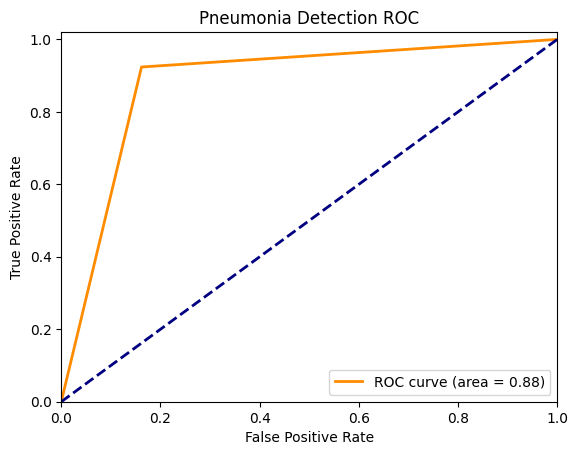

In [ ]:
from sklearn.metrics import roc_curve, auc, f1_score

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pneumonia Detection ROC')
plt.legend(loc="lower right")
plt.show()

##**6. Evaluation metric - comparison - confusion matrix**

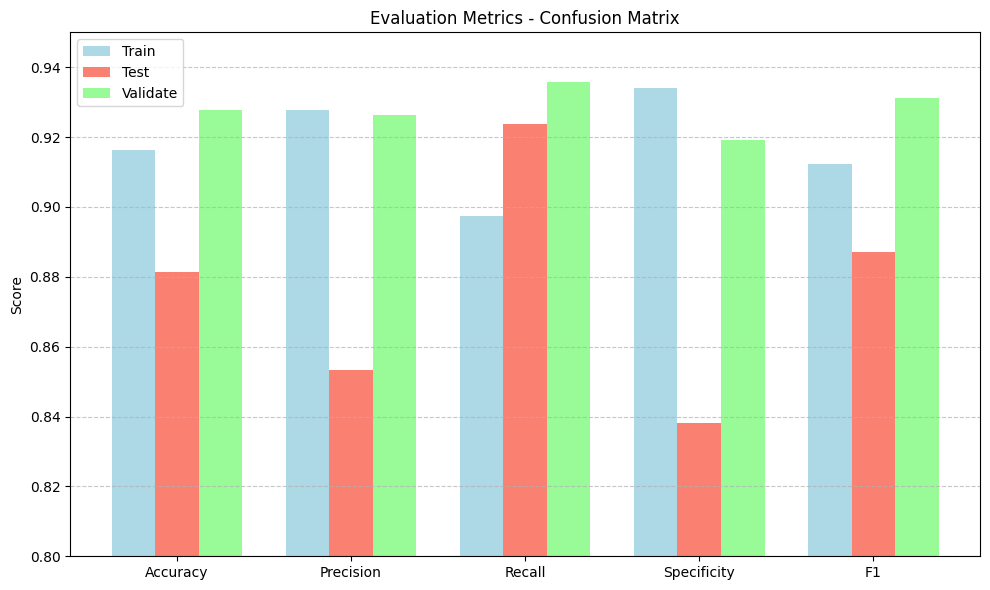

In [ ]:

metrics = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]

# Values
train_values = [train_accuracy, train_precision, train_recall, train_specificity, train_f1]
val_values  = [val_accuracy, val_precision, val_recall, val_specificity, val_f1]
test_values   = [test_accuracy, test_precision, test_recall, test_specificity, test_f1]


x = np.arange(len(metrics))
width = 0.25


plt.figure(figsize=(10, 6))
plt.bar(x - width, train_values, width, label='Train', color='lightblue')
plt.bar(x,         test_values,  width, label='Test',  color='salmon')
plt.bar(x + width, val_values,   width, label='Validate', color='palegreen')


plt.ylabel('Score')
plt.title('Evaluation Metrics - Confusion Matrix')
plt.xticks(x, metrics)
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Training With Transfer Learning

To compare the effect of transfer learning, we re-run the training using `pretrained=True` for DenseNet121.

Expected Outcome:
- Better convergence
- Higher initial accuracy
- More generalization on test data

This demonstrates the impact of transfer learning on medical image classification with limited data.

In [ ]:
model = torchvision.models.densenet121(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 109MB/s]


##1. Train the model
No of Epochs = 30 - early stopping triggered at 10th epoch

08:24:49 --- Epoch: 0	Train loss: 0.4337	Valid loss: 0.3337	Train accuracy: 94.03	Valid accuracy: 94.37
08:28:55 --- Epoch: 1	Train loss: 0.3740	Valid loss: 0.3097	Train accuracy: 94.69	Valid accuracy: 92.25
08:32:55 --- Epoch: 2	Train loss: 0.3650	Valid loss: 0.3146	Train accuracy: 94.26	Valid accuracy: 92.25
08:36:55 --- Epoch: 3	Train loss: 0.3601	Valid loss: 0.3098	Train accuracy: 94.32	Valid accuracy: 93.49
08:40:56 --- Epoch: 4	Train loss: 0.3569	Valid loss: 0.3245	Train accuracy: 95.20	Valid accuracy: 93.13
08:44:58 --- Epoch: 5	Train loss: 0.3448	Valid loss: 0.2935	Train accuracy: 95.54	Valid accuracy: 94.72
08:48:58 --- Epoch: 6	Train loss: 0.3433	Valid loss: 0.3164	Train accuracy: 95.26	Valid accuracy: 94.89
08:52:58 --- Epoch: 7	Train loss: 0.3432	Valid loss: 0.3146	Train accuracy: 95.50	Valid accuracy: 95.77
08:57:00 --- Epoch: 8	Train loss: 0.3356	Valid loss: 0.2958	Train accuracy: 96.48	Valid accuracy: 94.01
09:01:03 --- Epoch: 9	Train loss: 0.3342	Valid loss: 0.3224	Trai

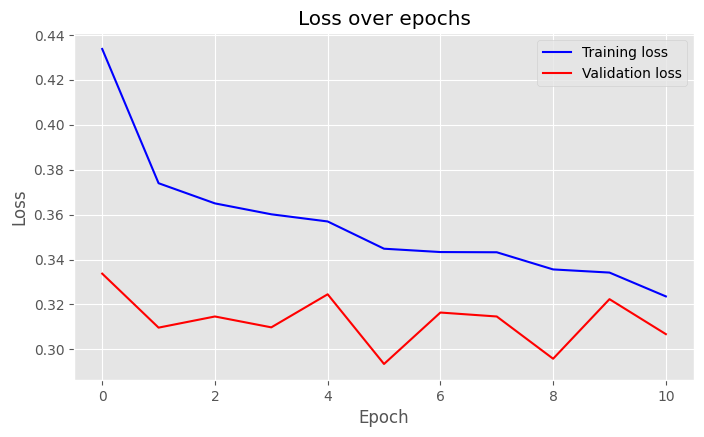

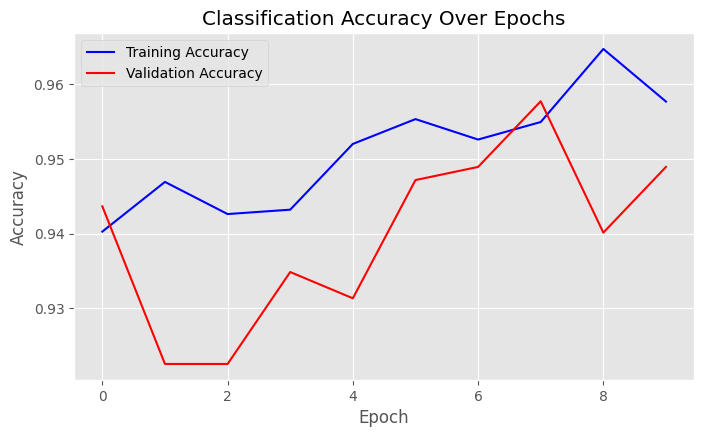

In [ ]:
model, optimizer, _ = training_loop(model, criterion, optimizer, train_loader, val_loader, N_EPOCHS, DEVICE)

##**2. Training Set Result**

Accuracy: 0.9579009203054631
Precision: 0.974155069582505
Recall: 0.9423076923076923
Specificity: 0.9740725967291584
F1: 0.9579667644183774



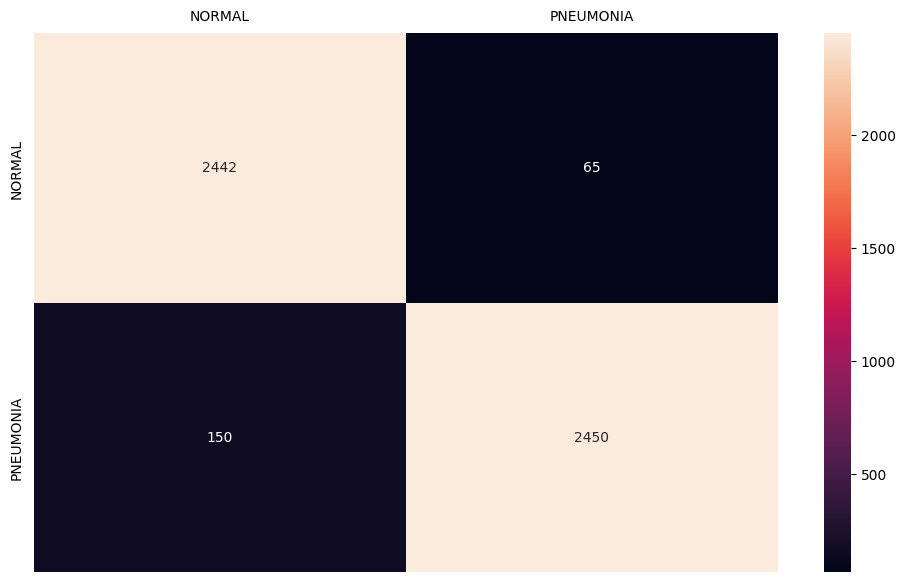

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn
import pandas as pd

test_batch_size = 20

y_pred = []
y_true = []

with torch.no_grad():
  model.eval()

  for inputs, labels in train_loader:

    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)

    probs = model(inputs)
    _, output = torch.max(probs, 1)

    output = output.data.cpu().numpy()
    y_pred.extend(output)

    labels = labels.data.cpu().numpy()
    y_true.extend(labels)

classes = ('NORMAL', 'PNEUMONIA')

cf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])

plt.figure(figsize=(12,7))
ax = sn.heatmap(df_cm, annot=True, fmt="d")
# ax.xaxis.tick_top()
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom=False, bottom=False, top=False, left=False, labeltop=True)
ax.xaxis.set_label_position("top")
plt.savefig("ConfusionMatrix.png")

tp = cf_matrix[1][1]
fp = cf_matrix[0][1]
tn = cf_matrix[0][0]
fn = cf_matrix[1][0]
accuracy = (tp + tn)/(tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)

train_accuracy = accuracy
train_precision = precision
train_recall = recall
train_specificity = specificity
train_f1 = f1

print(f"Accuracy: {train_accuracy}")
print(f"Precision: {train_precision}")
print(f"Recall: {train_recall}")
print(f"Specificity: {train_specificity}")
print(f"F1: {train_f1}")
print()


##**3. Validation Set Result**

Accuracy: 0.948943661971831
Precision: 0.9535714285714286
Recall: 0.9434628975265018
Specificity: 0.9543859649122807
F1: 0.9484902309058615



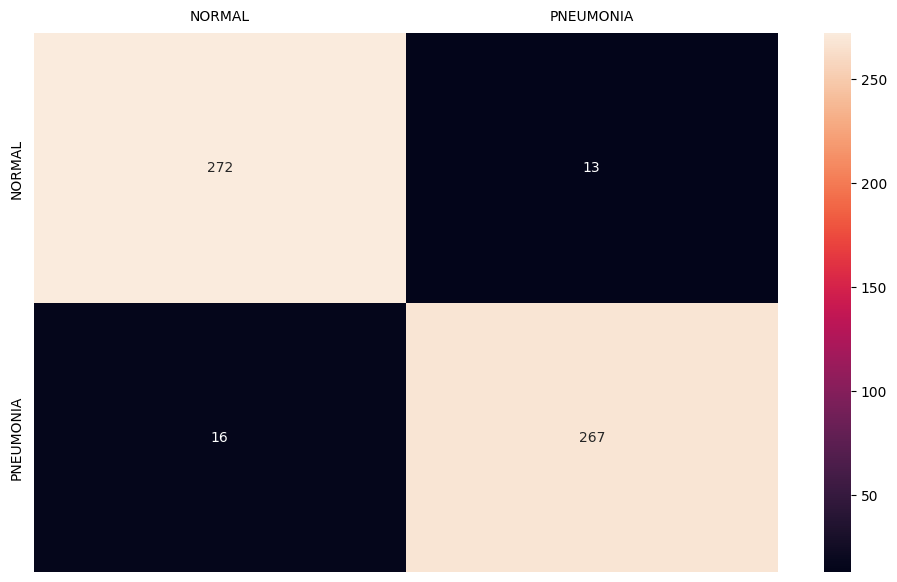

In [ ]:
test_batch_size = 20

y_pred = []
y_true = []

with torch.no_grad():
  model.eval()

  for inputs, labels in val_loader:

    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)

    probs = model(inputs)
    _, output = torch.max(probs, 1)

    output = output.data.cpu().numpy()
    y_pred.extend(output)

    labels = labels.data.cpu().numpy()
    y_true.extend(labels)

classes = ('NORMAL', 'PNEUMONIA')

cf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])

plt.figure(figsize=(12,7))
ax = sn.heatmap(df_cm, annot=True, fmt="d")
# ax.xaxis.tick_top()
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom=False, bottom=False, top=False, left=False, labeltop=True)
ax.xaxis.set_label_position("top")
plt.savefig("ConfusionMatrix.png")

tp = cf_matrix[1][1]
fp = cf_matrix[0][1]
tn = cf_matrix[0][0]
fn = cf_matrix[1][0]
accuracy = (tp + tn)/(tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)

val_accuracy = accuracy
val_precision = precision
val_recall = recall
val_specificity = specificity
val_f1 = f1

print(f"Accuracy: {val_accuracy}")
print(f"Precision: {val_precision}")
print(f"Recall: {val_recall}")
print(f"Specificity: {val_specificity}")
print(f"F1: {val_f1}")
print()


##**4. Test Set Result**

Accuracy: 0.9375650364203955
Precision: 0.9191321499013807
Recall: 0.9608247422680413
Specificity: 0.9138655462184874
F1: 0.9395161290322582



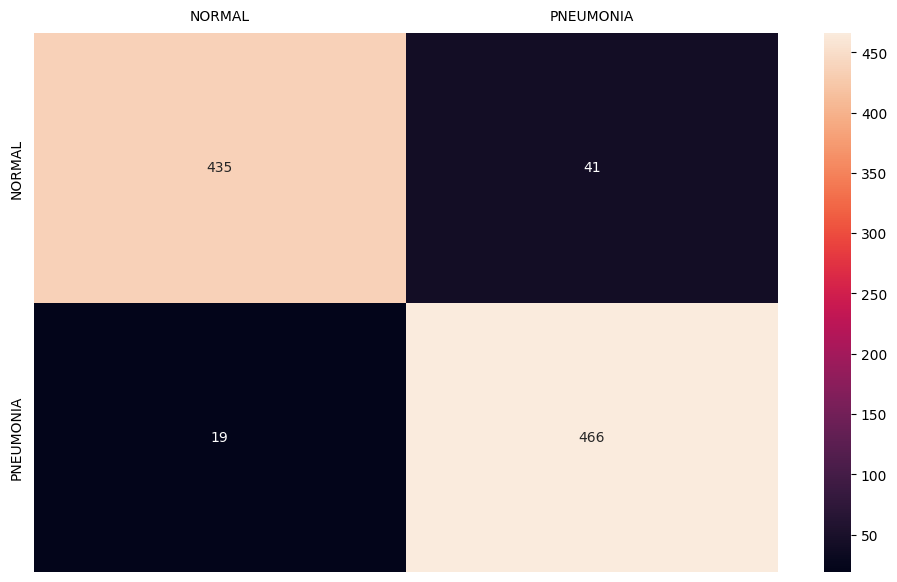

In [ ]:
test_batch_size = 20
test_dataset = ImageFolder(test_folder, transform=test_transformer)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)

y_pred = []
y_true = []

with torch.no_grad():
  model.eval()

  for inputs, labels in test_loader:

    inputs = inputs.to(DEVICE)
    labels = labels.to(DEVICE)

    probs = model(inputs)
    _, output = torch.max(probs, 1)

    output = output.data.cpu().numpy()
    y_pred.extend(output)

    labels = labels.data.cpu().numpy()
    y_true.extend(labels)

classes = ('NORMAL', 'PNEUMONIA')

cf_matrix = confusion_matrix(y_true, y_pred)

df_cm = pd.DataFrame(cf_matrix, index = [i for i in classes], columns = [i for i in classes])

plt.figure(figsize=(12,7))
ax = sn.heatmap(df_cm, annot=True, fmt="d")
# ax.xaxis.tick_top()
plt.tick_params(axis='both', which='major', labelsize=10, labelbottom=False, bottom=False, top=False, left=False, labeltop=True)
ax.xaxis.set_label_position("top")
plt.savefig("ConfusionMatrix.png")

tp = cf_matrix[1][1]
fp = cf_matrix[0][1]
tn = cf_matrix[0][0]
fn = cf_matrix[1][0]
accuracy = (tp + tn)/(tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
f1 = 2 * precision * recall / (precision + recall)

test_accuracy = accuracy
test_precision = precision
test_recall = recall
test_specificity = specificity
test_f1 = f1

print(f"Accuracy: {test_accuracy}")
print(f"Precision: {test_precision}")
print(f"Recall: {test_recall}")
print(f"Specificity: {test_specificity}")
print(f"F1: {test_f1}")
print()


##**5. Receiver Operating Characteristic (ROC) curve**

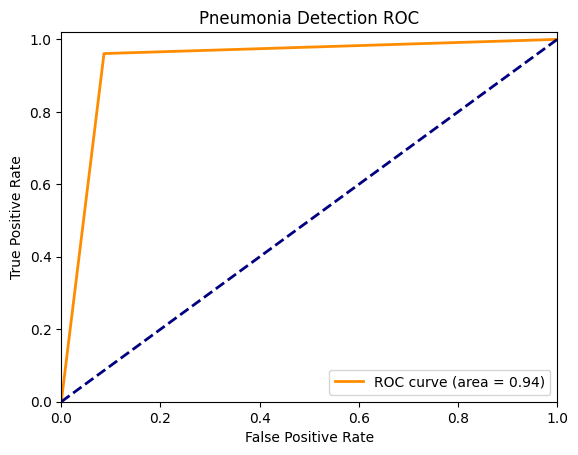

In [ ]:
from sklearn.metrics import roc_curve, auc, f1_score

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Pneumonia Detection ROC')
plt.legend(loc="lower right")
plt.show()

##**6. Evaluation metric - comparison - confusion matrix**

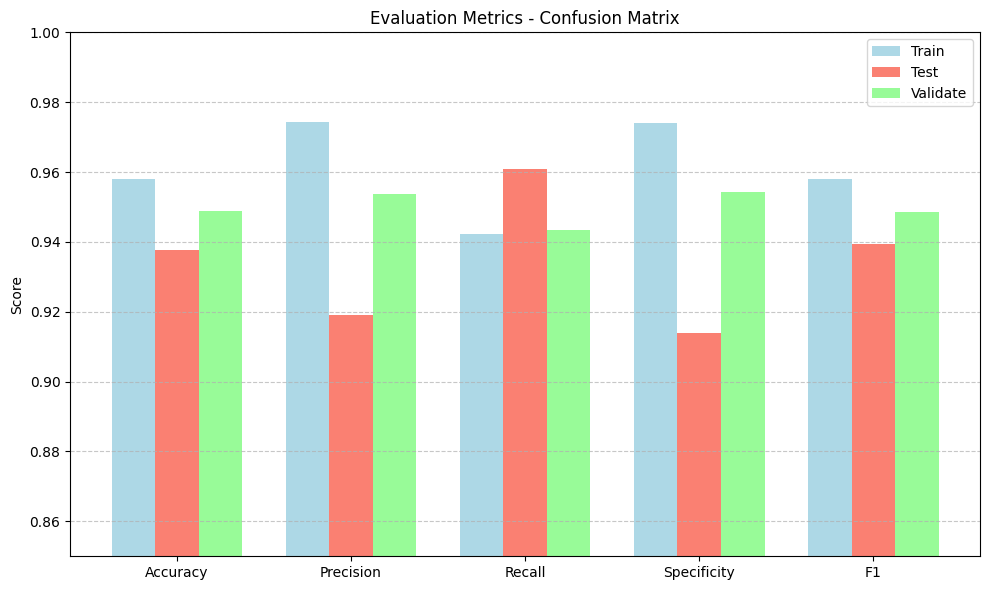

In [ ]:

metrics = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]

# Values
train_values = [train_accuracy, train_precision, train_recall, train_specificity, train_f1]
val_values  = [val_accuracy, val_precision, val_recall, val_specificity, val_f1]
test_values   = [test_accuracy, test_precision, test_recall, test_specificity, test_f1]


x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, train_values, width, label='Train', color='lightblue')
plt.bar(x,         test_values,  width, label='Test',  color='salmon')
plt.bar(x + width, val_values,   width, label='Validate', color='palegreen')


plt.ylabel('Score')
plt.title('Evaluation Metrics - Confusion Matrix')
plt.xticks(x, metrics)
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# List all modules in the features block with their names:


In [ ]:
# List all modules in the features block with their names:
for name, module in model.features.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print(name, module)


conv0 Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
denseblock1.denselayer1.conv1 Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
denseblock1.denselayer1.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
denseblock1.denselayer2.conv1 Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
denseblock1.denselayer2.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
denseblock1.denselayer3.conv1 Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
denseblock1.denselayer3.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
denseblock1.denselayer4.conv1 Conv2d(160, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
denseblock1.denselayer4.conv2 Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
denseblock1.denselayer5.conv1 Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
denseblock1.d

# Result Comparison - With and Without Transfer Learning - DenseNet

| Metric         | Pretrained Model | Without Pretrained Model |
| -------------- | ---------------- | -------------------- |
| Test Accuracy  | 93.7%              | 88.13%                  |
| Test F1        | 93.95%              | 88.71%                  |
| Test Recall    | 96.08%              | 92.37%                  |
| Test Precision | 91.91%              | 85.33%                  |


## Interpretation of Results

**The model with pretrained DenseNet121 significantly outperformed the version trained from scratch across all key test metrics.**

* **Accuracy** improved from **88.13% ➜ 93.7%**, showing better overall correctness on unseen data.
* **F1 Score** rose from **88.71% ➜ 93.95%**, indicating stronger balance between precision and recall.
* **Recall** increased from **92.37% ➜ 96.08%**, meaning the pretrained model caught more actual pneumonia cases.
* **Precision** improved from **85.33% ➜ 91.91%**, meaning fewer false positives when predicting pneumonia.



#Conclusion:

**Transfer learning using pretrained DenseNet121 led to better generalization, faster convergence, and higher diagnostic reliability.**
This supports the use of pretrained CNNs in medical imaging tasks, especially when working with limited data.
